# EfficientNetV2-S — expérience de classification multi-label

Notebook isolé pour **EfficientNetV2-S** (`efficientnet_v2_s`). La démarche est la même pour chaque
architecture : séparer les données, geler l'extracteur, augmenter, mesurer le
F1 du serveur, puis lire les courbes d'erreur avant de toucher au test.

| | |
| --- | --- |
| Paramètres | 21,5 M |
| Coût | 8,37 GFLOPS à 224 px |
| ImageNet top-1 | 84,2 % |
| Batch de départ | 16 |
| Pas, tête seule | 1e-3 |
| Pas, fine-tuning | 5e-5 |

Note : le plus precis sur ImageNet parmi les candidats.

Poids torchvision : `EfficientNet_V2_S_Weights.DEFAULT`. Le réseau renvoie des logits ;
la sigmoïde n'est appliquée qu'au moment des métriques.

1. Découpage train / validation / test local
2. Augmentation géométrique et photométrique
3. Baseline : extracteur gelé, tête seule
4. Étape optimisée : augmentation plus forte, dropout, weight decay, dégel
5. Test local, une seule fois
6. Diagnostic biais / variance
7. Soumission au leaderboard, sur les images de test sans étiquette


## Configuration

`FULL_TRAIN = False` limite l'exécution à 512 images et une époque, pour
vérifier que le notebook s'enchaîne. Le passer à `True` lance l'expérience
complète : 5 époques de tête gelée, puis 8 époques de fine-tuning, sur les
65 000 images annotées.

Le coût Asymmetric Loss (`asl`) est celui retenu pour le déséquilibre des
80 classes. L'erreur tracée plus bas vaut **100 × (1 − F1 serveur)**.


In [2]:
MODEL_NAME = 'efficientnet_v2_s'
FULL_TRAIN = True

SEED = 42
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
IMAGE_SIZE = 224
RESIZE_MODE = "pad"
LOSS = "asl"

BATCH_SIZE = 16
LR_HEAD = 1e-3
LR_FINETUNE = 5e-5
WEIGHT_DECAY_BASELINE = 0.0
WEIGHT_DECAY_FINETUNE = 1e-4
DROPOUT_FINETUNE = 0.3

# FULL_TRAIN lance la config complete (5 epoques tete gelee, puis 8 de fine-tuning).
# Sinon : 512 images et 1 epoque, pour verifier le pipeline.
EPOCHS_BASELINE = 5 if FULL_TRAIN else 1
EPOCHS_FINETUNE = 8 if FULL_TRAIN else 1
MAX_IMAGES = None if FULL_TRAIN else 512
NUM_WORKERS = 0


## Environnement

Le notebook ajoute `src/` au chemin, fixe la graine, et choisit le GPU s'il
est visible. La précision mixte n'est activée que sur CUDA.


In [3]:
import sys
from pathlib import Path

def _find_repo() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "src" / "coco_mlc").is_dir():
            return candidate
    raise FileNotFoundError(
        "Racine du projet introuvable (dossier src/coco_mlc). "
        "Lance le notebook depuis le depot IAV_MS_COCO."
    )

REPO = _find_repo()
for _site in (REPO / ".venv").glob("Lib/site-packages"):
    if _site.is_dir() and str(_site) not in sys.path:
        sys.path.insert(0, str(_site))
for _site in (REPO / ".venv").glob("lib/python*/site-packages"):
    if _site.is_dir() and str(_site) not in sys.path:
        sys.path.insert(0, str(_site))
sys.path.insert(0, str(REPO / "src"))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import DataLoader
from torchinfo import summary

from coco_mlc.config import CLASSES, PATHS
from coco_mlc.data import (
    COCOTrainImageDataset,
    IMAGENET_MEAN,
    IMAGENET_STD,
    TransformSubset,
    build_transforms,
    get_three_way_split,
    load_label_matrix,
)
from coco_mlc.diagnostics import (
    diagnose_errors,
    error_percent,
    format_diagnosis,
    plot_error_curves,
    plot_model_diagram,
    save_history,
)
from coco_mlc.engine import describe_device, evaluate, fit_stage, pick_device, save_checkpoint
from coco_mlc.losses import build_criterion
from coco_mlc.metrics import all_metrics, format_metrics
from coco_mlc.models import (
    build_model,
    count_parameters,
    load_compatible_weights,
)
from coco_mlc.thresholds import tune_per_class_thresholds
from coco_mlc.utils import set_seed

set_seed(SEED)
device = pick_device()
USE_AMP = device.type == "cuda"
OUT_DIR = PATHS.outputs / "notebooks" / MODEL_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(describe_device(device), "| amp" if USE_AMP else "| fp32")
print("Résultats :", OUT_DIR)


cuda (NVIDIA GeForce RTX 4060 Ti) | amp
Résultats : C:\Users\trans\OneDrive\Documents\INSA Lyon\5TCA\IAV\IAV_MS_COCO\outputs\notebooks\efficientnet_v2_s


C:\Users\trans\OneDrive\Documents\INSA Lyon\5TCA\IAV\IAV_MS_COCO\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Préparation et séparation des données

Les 65 000 images annotées sont coupées en trois ensembles **stratifiés** et
disjoints (graine 42) :

- **train (70 %)** — apprentissage des poids ;
- **validation (15 %)** — choix des hyperparamètres, arrêt, seuils ;
- **test local (15 %)** — généralisation, consulté une seule fois en fin de notebook.

Le cache est `outputs/split_three_stratified_0.7_0.15_0.15_42.json`. Il ne
remplace pas le découpage 80/20 des scripts. Un essai avec `MAX_IMAGES` écrit
un fichier à part, pour ne pas écraser le split complet.

Les classes rares (`hair drier`, `toaster`) dominent le F1 du serveur : le
tableau vérifie qu'elles sont présentes dans les trois ensembles.


In [4]:
PATHS.check()
ids, Y = load_label_matrix()
if MAX_IMAGES is not None:
    ids = ids[:MAX_IMAGES]
    Y = Y[:MAX_IMAGES]

cache_path = PATHS.outputs / f"split_three_stratified_0.7_0.15_0.15_{SEED}.json"
if MAX_IMAGES is not None:
    cache_path = cache_path.with_name(f"{cache_path.stem}_{len(Y)}{cache_path.suffix}")
train_idx, val_idx, test_idx = get_three_way_split(
    Y,
    val_fraction=VAL_FRACTION,
    test_fraction=TEST_FRACTION,
    seed=SEED,
    cache_path=cache_path,
)
train_set, val_set, test_set = set(train_idx), set(val_idx), set(test_idx)
assert train_set.isdisjoint(val_set)
assert train_set.isdisjoint(test_set)
assert val_set.isdisjoint(test_set)
assert len(train_set) + len(val_set) + len(test_set) == len(Y)

n = len(Y)
print(f"{n} images annotées")
for label, idx in ("train", train_idx), ("validation", val_idx), ("test local", test_idx):
    print(f"  {label:12s} {len(idx):6d}  ({100 * len(idx) / n:.1f} %)")

counts = pd.DataFrame({
    "classe": list(CLASSES),
    "train": Y[train_idx].sum(axis=0),
    "validation": Y[val_idx].sum(axis=0),
    "test": Y[test_idx].sum(axis=0),
})
rare = counts[counts["classe"].isin(["hair drier", "toaster", "person"])]
print()
print(rare.to_string(index=False))
print()
print("Le test officiel (images/test) n'a pas d'étiquettes : il sert à la soumission, pas à ce F1.")


65000 images annotées
  train         45525  (70.0 %)
  validation     9724  (15.0 %)
  test local     9751  (15.0 %)

    classe  train  validation  test
    person  24846        5324  5324
   toaster     82          18    17
hair drier     72          15    15

Le test officiel (images/test) n'a pas d'étiquettes : il sert à la soumission, pas à ce F1.


## Augmentation de données

La géométrie reste le mode `pad` : un recadrage central supprimerait des
objets dont l'étiquette resterait positive. Deux paliers ensuite :

- **baseline** — retournement horizontal ;
- **étape optimisée** — rotation, translation, échelle (`RandomAffine`) et
  jitter photométrique (`ColorJitter`).

Les loaders de validation, de test, et d'évaluation du train n'appliquent
aucune transformation aléatoire. L'écart train/validation mesure alors la
généralisation, pas le bruit de l'augmentation.


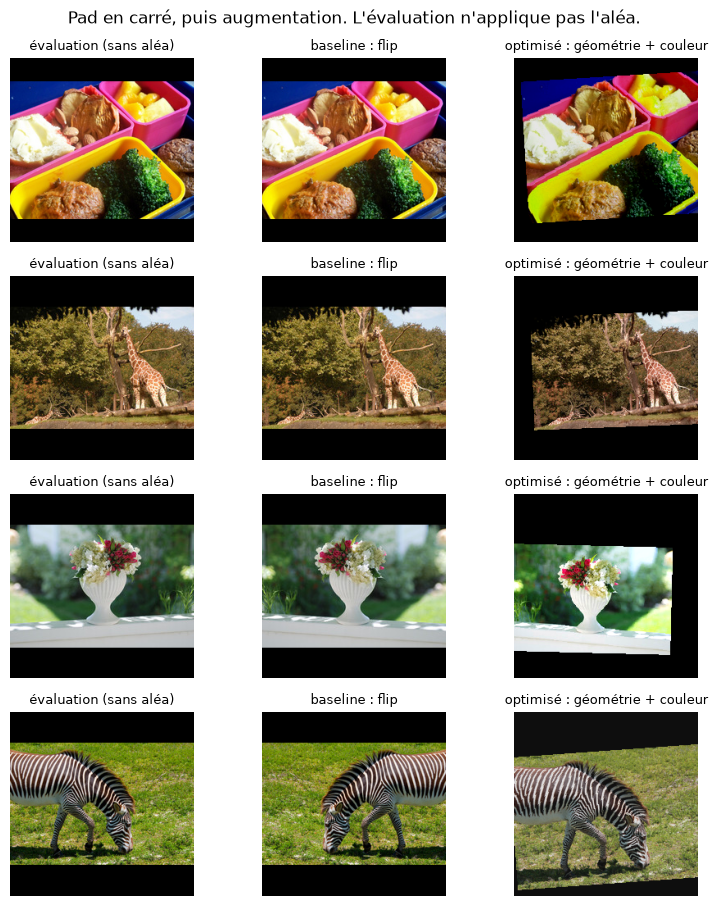

In [5]:
eval_tf = build_transforms(IMAGE_SIZE, train=False, resize_mode=RESIZE_MODE)
train_tf = build_transforms(IMAGE_SIZE, train=True, resize_mode=RESIZE_MODE, augment="flip")
experiment_tf = build_transforms(
    IMAGE_SIZE, train=True, resize_mode=RESIZE_MODE, augment="experiment",
)

preview = COCOTrainImageDataset(max_images=MAX_IMAGES)
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def show_tensor(ax, tensor, title):
    image = (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(image)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

n_show = 4
fig, axes = plt.subplots(n_show, 3, figsize=(8, 2.3 * n_show))
for row in range(n_show):
    image, _labels = preview[row]
    show_tensor(axes[row, 0], eval_tf(image), "évaluation (sans aléa)")
    show_tensor(axes[row, 1], train_tf(image), "baseline : flip")
    show_tensor(axes[row, 2], experiment_tf(image), "optimisé : géométrie + couleur")
fig.suptitle("Pad en carré, puis augmentation. L'évaluation n'applique pas l'aléa.")
fig.tight_layout()
plt.show()


## Chargeurs

Le test local est construit ici pour ne pas être redéfini plus tard, mais
aucune métrique ne le lit avant la section de généralisation.


In [6]:
base = COCOTrainImageDataset(max_images=MAX_IMAGES)

def make_loader(indices, transform, shuffle):
    return DataLoader(
        TransformSubset(base, indices, transform),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        drop_last=shuffle and len(indices) >= 2 * BATCH_SIZE,
        num_workers=NUM_WORKERS,
        persistent_workers=NUM_WORKERS > 0,
        pin_memory=device.type == "cuda",
    )

train_loader = make_loader(train_idx, train_tf, shuffle=True)
train_eval_loader = make_loader(train_idx, eval_tf, shuffle=False)
val_loader = make_loader(val_idx, eval_tf, shuffle=False)
test_loader = make_loader(test_idx, eval_tf, shuffle=False)
print(
    f"batches train {len(train_loader)} | "
    f"éval train {len(train_eval_loader)} | "
    f"validation {len(val_loader)} | test {len(test_loader)}"
)


batches train 2845 | éval train 2846 | validation 608 | test 610


## Baseline — apprentissage par transfert

L'extracteur ImageNet est gelé. Seule la tête linéaire, réinitialisée à
80 logits, est apprise. Le biais de sortie part de la log-cote des
prévalences du **train** (pas de la validation, pas du test).

Le schéma distingue le prétraitement, l'extracteur gelé et la tête
entraînable. Le tableau `torchinfo` détaille les blocs du réseau fine-tuné.


20.3 M paramètres, dont 0.102 M entraînables (la tête)


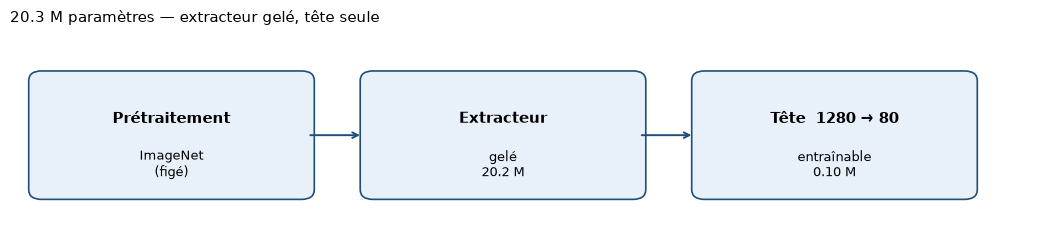

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 80]                   --
├─Sequential: 1-1                                       [1, 1280, 7, 7]           --
│    └─Conv2dNormActivation: 2-1                        [1, 24, 112, 112]         --
│    │    └─Conv2d: 3-1                                 [1, 24, 112, 112]         (648)
│    │    └─BatchNorm2d: 3-2                            [1, 24, 112, 112]         (48)
│    │    └─SiLU: 3-3                                   [1, 24, 112, 112]         --
│    └─Sequential: 2-2                                  [1, 24, 112, 112]         --
│    │    └─FusedMBConv: 3-4                            [1, 24, 112, 112]         (5,232)
│    │    └─FusedMBConv: 3-5                            [1, 24, 112, 112]         (5,232)
│    └─Sequential: 2-3                                  [1, 48, 56, 56]           --
│    │    └─FusedMBConv: 3-6                 

In [7]:
prior = Y[train_idx].mean(axis=0)
model_baseline = build_model(
    MODEL_NAME,
    pretrained=True,
    freeze_backbone=True,
    dropout=0.0,
    prior=prior,
).to(device)

total, trainable = count_parameters(model_baseline)
print(f"{total / 1e6:.1f} M paramètres, dont {trainable / 1e6:.3f} M entraînables (la tête)")
fig = plot_model_diagram(model_baseline, frozen=True)
plt.show()
summary(model_baseline, input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE), depth=3)


## Entraînement de la tête

AdamW, pas `LR_HEAD`, sans weight decay. Le scheduler cosinus est calé sur
le nombre de mini-batches de cette étape. À chaque époque on enregistre
précision, rappel et F1, sur le train **sans** augmentation et sur la
validation, au seuil fixe 0,5.


  epoque  1/5  train_loss=0.0312  val_loss=0.0261  P/R/F1 train=0.296/0.785/0.430  val=0.274/0.699/0.394  erreur train=57.03%  val=60.65%


  epoque  2/5  train_loss=0.0264  val_loss=0.0252  P/R/F1 train=0.310/0.806/0.448  val=0.275/0.702/0.396  erreur train=55.20%  val=60.44%


  epoque  3/5  train_loss=0.0252  val_loss=0.0245  P/R/F1 train=0.318/0.821/0.458  val=0.278/0.708/0.400  erreur train=54.20%  val=60.05%


  epoque  4/5  train_loss=0.0242  val_loss=0.0241  P/R/F1 train=0.315/0.854/0.460  val=0.276/0.709/0.397  erreur train=53.95%  val=60.26%


  epoque  5/5  train_loss=0.0236  val_loss=0.0241  P/R/F1 train=0.314/0.862/0.460  val=0.276/0.719/0.399  erreur train=54.01%  val=60.14%


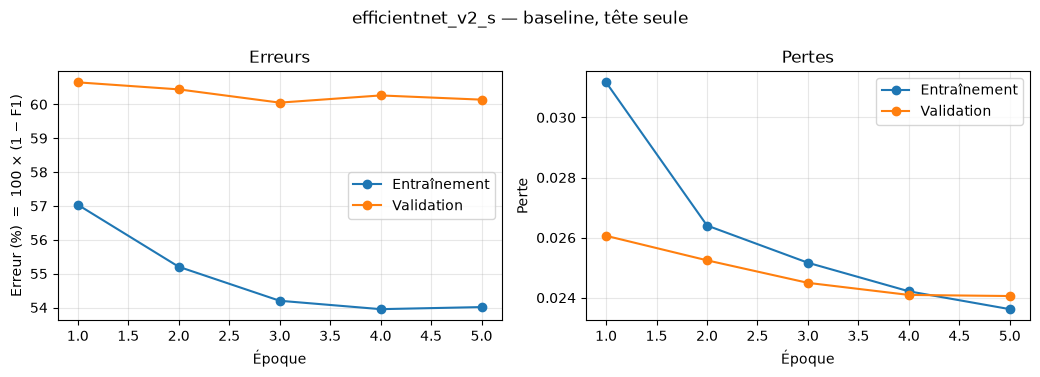

Dernière époque (seuil 0,5) — précision train/val 0.314/0.276 | rappel 0.862/0.719 | F1 0.460/0.399


In [8]:
criterion = build_criterion(LOSS)
optimizer = torch.optim.AdamW(
    [p for p in model_baseline.parameters() if p.requires_grad],
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY_BASELINE,
)
baseline_steps = EPOCHS_BASELINE * max(len(train_loader), 1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(baseline_steps, 1))

history_baseline = fit_stage(
    model_baseline,
    train_loader,
    train_eval_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    EPOCHS_BASELINE,
    scheduler=scheduler,
    amp=USE_AMP,
    desc="baseline",
)
save_history(history_baseline, OUT_DIR / "history_baseline.csv")
save_checkpoint(OUT_DIR / "baseline.pth", model_baseline, {
    "kind": "notebook_baseline",
    "backbone": MODEL_NAME,
    "freeze_backbone": True,
    "dropout": 0.0,
    "loss": LOSS,
    "image_size": IMAGE_SIZE,
    "resize_mode": RESIZE_MODE,
    "seed": SEED,
})

fig = plot_error_curves(history_baseline, title=f"{MODEL_NAME} — baseline, tête seule")
plt.show()
last_baseline = history_baseline[-1]
print(
    "Dernière époque (seuil 0,5) — "
    f"précision train/val {last_baseline['train_precision']:.3f}/{last_baseline['val_precision']:.3f} | "
    f"rappel {last_baseline['train_recall']:.3f}/{last_baseline['val_recall']:.3f} | "
    f"F1 {last_baseline['train_f1']:.3f}/{last_baseline['val_f1']:.3f}"
)


## Étape optimisée

Trois leviers, dans cette cellule, pour pouvoir les modifier ensemble ou
les commenter un par un :

- augmentation `experiment` à la place du simple flip ;
- dropout sur la tête et weight decay (norme L2) ;
- dégel de tout le réseau, avec un pas plus faible.

Les poids de la baseline sont repris, y compris la tête déjà adaptée aux
80 classes. Le test local n'entre toujours pas dans les décisions.


Tenseurs repris de la baseline : 782
20.3 M paramètres, dont 20.3 M entraînables


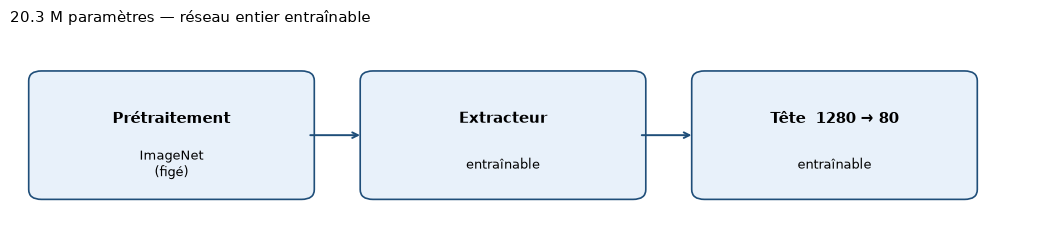

fine-tuning 1/8:   0%|          | 0/2845 [00:00<?, ?it/s]C:\Users\trans\OneDrive\Documents\INSA Lyon\5TCA\IAV\IAV_MS_COCO\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


  epoque  1/8  train_loss=nan  val_loss=0.0200  P/R/F1 train=0.334/0.826/0.475  val=0.307/0.742/0.435  erreur train=52.48%  val=56.53%


  epoque  2/8  train_loss=0.0230  val_loss=0.0195  P/R/F1 train=0.359/0.852/0.505  val=0.325/0.757/0.455  erreur train=49.50%  val=54.51%


  epoque  3/8  train_loss=0.0212  val_loss=0.0192  P/R/F1 train=0.357/0.888/0.509  val=0.325/0.792/0.461  erreur train=49.09%  val=53.91%


  epoque  4/8  train_loss=0.0198  val_loss=0.0188  P/R/F1 train=0.389/0.890/0.542  val=0.342/0.767/0.473  erreur train=45.82%  val=52.69%


  epoque  5/8  train_loss=0.0187  val_loss=0.0183  P/R/F1 train=0.414/0.913/0.570  val=0.355/0.754/0.482  erreur train=43.02%  val=51.77%


  epoque  6/8  train_loss=0.0179  val_loss=0.0180  P/R/F1 train=0.443/0.911/0.596  val=0.365/0.735/0.488  erreur train=40.37%  val=51.19%


  epoque  7/8  train_loss=0.0173  val_loss=0.0181  P/R/F1 train=0.453/0.914/0.606  val=0.375/0.738/0.497  erreur train=39.44%  val=50.28%


  epoque  8/8  train_loss=0.0171  val_loss=0.0178  P/R/F1 train=0.448/0.910/0.601  val=0.375/0.740/0.497  erreur train=39.92%  val=50.26%


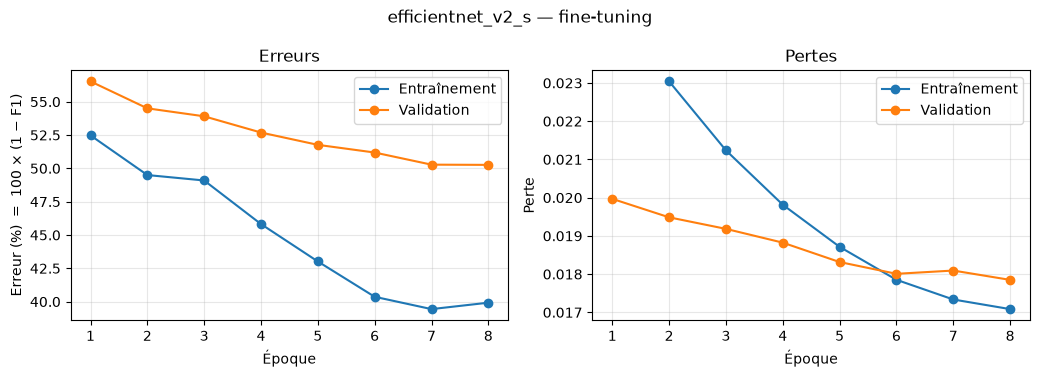

Dernière époque (seuil 0,5) — précision train/val 0.448/0.375 | rappel 0.910/0.740 | F1 0.601/0.497


In [9]:
train_loader_ft = make_loader(train_idx, experiment_tf, shuffle=True)
model_ft = build_model(
    MODEL_NAME,
    pretrained=True,
    freeze_backbone=False,
    dropout=DROPOUT_FINETUNE,
    prior=prior,
).to(device)
copied = load_compatible_weights(model_ft, model_baseline)
print(f"Tenseurs repris de la baseline : {len(copied)}")

total_ft, trainable_ft = count_parameters(model_ft)
print(f"{total_ft / 1e6:.1f} M paramètres, dont {trainable_ft / 1e6:.1f} M entraînables")
fig = plot_model_diagram(model_ft, frozen=False)
plt.show()

optimizer_ft = torch.optim.AdamW(
    model_ft.parameters(),
    lr=LR_FINETUNE,
    weight_decay=WEIGHT_DECAY_FINETUNE,
)
finetune_steps = EPOCHS_FINETUNE * max(len(train_loader_ft), 1)
scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft, T_max=max(finetune_steps, 1),
)
history_ft = fit_stage(
    model_ft,
    train_loader_ft,
    train_eval_loader,
    val_loader,
    criterion,
    optimizer_ft,
    device,
    EPOCHS_FINETUNE,
    scheduler=scheduler_ft,
    amp=USE_AMP,
    desc="fine-tuning",
)
save_history(history_ft, OUT_DIR / "history_finetune.csv")
save_checkpoint(OUT_DIR / "finetune.pth", model_ft, {
    "kind": "notebook_finetune",
    "backbone": MODEL_NAME,
    "freeze_backbone": False,
    "dropout": DROPOUT_FINETUNE,
    "loss": LOSS,
    "image_size": IMAGE_SIZE,
    "resize_mode": RESIZE_MODE,
    "seed": SEED,
})

fig = plot_error_curves(history_ft, title=f"{MODEL_NAME} — fine-tuning")
plt.show()
last_ft = history_ft[-1]
print(
    "Dernière époque (seuil 0,5) — "
    f"précision train/val {last_ft['train_precision']:.3f}/{last_ft['val_precision']:.3f} | "
    f"rappel {last_ft['train_recall']:.3f}/{last_ft['val_recall']:.3f} | "
    f"F1 {last_ft['train_f1']:.3f}/{last_ft['val_f1']:.3f}"
)


## Généralisation — test local, une seule fois

Les seuils par classe sont calibrés **uniquement** sur la validation, puis
appliqués au train, à la validation et au test. Le test ne sert pas à choisir
le seuil. Les scores du réseau ne sont calculés qu'une fois par ensemble.


In [10]:
def collect(loader, net, desc):
    results, _per_class, scores, targets = evaluate(
        loader, net, criterion, device,
        thresholds=0.5, return_scores=True, amp=USE_AMP, desc=desc,
    )
    return results, scores, targets

train_05, train_scores, train_targets = collect(train_eval_loader, model_ft, "train")
val_05, val_scores, val_targets = collect(val_loader, model_ft, "validation")
test_05, test_scores, test_targets = collect(test_loader, model_ft, "test local")

thresholds, _f1_val, _hist = tune_per_class_thresholds(val_scores, val_targets)

def at(scores, targets, th):
    return all_metrics(scores, targets, thresholds=th)

train_cal = at(train_scores, train_targets, thresholds)
val_cal = at(val_scores, val_targets, thresholds)
test_cal = at(test_scores, test_targets, thresholds)

rows = []
for split, raw, calibrated in (
    ("train", train_05, train_cal),
    ("validation", val_05, val_cal),
    ("test local", test_05, test_cal),
):
    rows.append({
        "ensemble": split,
        "précision @0,5": raw["precision"],
        "rappel @0,5": raw["recall"],
        "F1 @0,5": raw["f1"],
        "erreur @0,5 (%)": error_percent(raw["f1"]),
        "précision calibrée": calibrated["precision"],
        "rappel calibré": calibrated["recall"],
        "F1 calibré": calibrated["f1"],
        "erreur calibrée (%)": error_percent(calibrated["f1"]),
    })
report = pd.DataFrame(rows).set_index("ensemble")
print(report.round(4).to_string())
print()
print("Validation calibrée :", format_metrics(val_cal))
print("Test local calibré  :", format_metrics(test_cal))
report.to_csv(OUT_DIR / "generalization.csv")


  passe 1: F1 validation = 0.6874
  passe 2: F1 validation = 0.7081
  passe 3: F1 validation = 0.7081
  passe 4: F1 validation = 0.7082
            précision @0,5  rappel @0,5  F1 @0,5  erreur @0,5 (%)  précision calibrée  rappel calibré  F1 calibré  erreur calibrée (%)
ensemble                                                                                                                              
train               0.4483       0.9104   0.6008          39.9234              0.7515          0.7559      0.7537              24.6296
validation          0.3745       0.7401   0.4974          50.2637              0.7352          0.6831      0.7082              29.1810
test local          0.3847       0.7653   0.5120          48.7975              0.7156          0.6313      0.6708              32.9208

Validation calibrée : f1=0.7082 | precision=0.7352 | recall=0.6831 | accuracy=0.8001 | macro_f1=0.6850 | micro_f1=0.5489 | mAP=0.7628
Test local calibré  : f1=0.6708 | precision=0.7156 | r

## Diagnostic

L'erreur est **100 × (1 − F1 serveur)**. On compare d'abord l'entraînement et
la validation. Le test n'intervient qu'ensuite.

- **Sous-apprentissage (biais élevé).** Erreurs hautes et proches, par exemple
  10 % au train et 12 % en validation. Pistes : réseau plus volumineux,
  entraîner plus longtemps, changer d'optimiseur, recherche d'hyperparamètres.
- **Surapprentissage (variance élevée).** Écart fort, par exemple 1 % au train
  et 10 % en validation. Pistes : agrandir et diversifier le train, renforcer
  l'augmentation, régulariser (L2, dropout), recherche d'hyperparamètres.
- **Les deux.** Erreurs hautes et écart fort, par exemple 10 % et 20 %.
  Appliquer les deux listes d'actions.
- **Modèle idéal.** Erreurs très basses et proches, par exemple 0,5 % et 1 %.
- **Mauvaise généralisation au test.** Le test local est nettement pire que la
  validation. Constituer une validation plus grande et plus diversifiée : la
  validation a été surajustée. Ne pas retoucher les hyperparamètres sur ce test.

Un écart qui ne tombe dans aucun de ces régimes est signalé comme cas
intermédiaire. L'affichage reprend le fine-tuning au seuil 0,5, puis le point
de fonctionnement après calibration. Le détail est enregistré dans
`outputs/notebooks/<architecture>/diagnosis.json`.


In [11]:
import json

def _last_epoch(row):
    return {
        "precision_train": row["train_precision"],
        "precision_val": row["val_precision"],
        "recall_train": row["train_recall"],
        "recall_val": row["val_recall"],
        "f1_train": row["train_f1"],
        "f1_val": row["val_f1"],
    }

diagnosis = {
    "notebook": f"exp_{MODEL_NAME}.ipynb",
    "model": MODEL_NAME,
    "baseline_threshold_0_5": {
        "last_epoch": _last_epoch(last_baseline),
        "diagnosis": diagnose_errors(
            last_baseline["train_error"],
            last_baseline["val_error"],
        ),
    },
    "finetune_threshold_0_5": {
        "last_epoch": _last_epoch(last_ft),
        "diagnosis": diagnose_errors(
            last_ft["train_error"],
            last_ft["val_error"],
            test_error=error_percent(test_05["f1"]),
        ),
    },
    "calibrated": {
        "diagnosis": diagnose_errors(
            error_percent(train_cal["f1"]),
            error_percent(val_cal["f1"]),
            test_error=error_percent(test_cal["f1"]),
        ),
    },
}
diagnosis_path = OUT_DIR / "diagnosis.json"
diagnosis_path.write_text(
    json.dumps(diagnosis, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
print("Diagnostic enregistré :", diagnosis_path)
print()
print(
    "Fine-tuning, seuil 0,5 — "
    f"F1 train/val/test {last_ft['train_f1']:.3f}/{last_ft['val_f1']:.3f}/{test_05['f1']:.3f}"
)
print(format_diagnosis(diagnosis["finetune_threshold_0_5"]["diagnosis"]))
print()
print(
    "Seuils calibrés — "
    f"F1 train/val/test {train_cal['f1']:.3f}/{val_cal['f1']:.3f}/{test_cal['f1']:.3f}"
)
print(format_diagnosis(diagnosis["calibrated"]["diagnosis"]))


Diagnostic enregistré : C:\Users\trans\OneDrive\Documents\INSA Lyon\5TCA\IAV\IAV_MS_COCO\outputs\notebooks\efficientnet_v2_s\diagnosis.json

Fine-tuning, seuil 0,5 — F1 train/val/test 0.601/0.497/0.512
Sous-apprentissage et surapprentissage simultanés
F1 train 0.601 | validation 0.497 | test 0.512
Erreur train 39.9 % | validation 50.3 % | écart +10.3 pts
Test 48.8 % | écart avec la validation -1.5 pts
Erreurs hautes, et un écart net : apprentissage incomplet et généralisation faible.

Seuils calibrés — F1 train/val/test 0.754/0.708/0.671
Cas intermédiaire
F1 train 0.754 | validation 0.708 | test 0.671
Erreur train 24.6 % | validation 29.2 % | écart +4.6 pts
Test 32.9 % | écart avec la validation +3.7 pts
Ni le niveau ni l'écart ne correspondent à un des quatre exemples types. Le test local est nettement pire que la validation.


## Soumission — leaderboard

Le test local a des étiquettes : il mesure la généralisation, il ne part pas
au serveur. Cette cellule applique le réseau fine-tuné aux images de
`images/test`, avec les seuils calibrés sur la validation seulement.

Le JSON suit le format du leaderboard : une clé par image (12 chiffres, sans
extension), une liste d'indices de classes. Il est écrit dans
`submissions/exp_<architecture>.json`.


In [12]:
import json
import re

import torch
from coco_mlc.data import COCOTestImageDataset
from coco_mlc.thresholds import apply_thresholds

server_set = COCOTestImageDataset(transform=eval_tf)
server_loader = DataLoader(
    server_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
)

chunks = []
model_ft.eval()
with torch.inference_mode():
    for images, _stems in server_loader:
        images = images.to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, enabled=USE_AMP):
            logits = model_ft(images)
        chunks.append(torch.sigmoid(logits.float()).cpu())
server_scores = torch.cat(chunks)
decisions = apply_thresholds(server_scores, thresholds, min_labels=1)

predictions = {
    str(image_id): [int(c) for c in torch.nonzero(row, as_tuple=False).flatten().tolist()]
    for image_id, row in zip(server_set.ids, decisions)
}

problems = []
if len(predictions) != len(server_set):
    problems.append(f"{len(predictions)} entrées au lieu de {len(server_set)}")
bad_ids = [key for key in predictions if re.fullmatch(r"\d{12}", key) is None]
if bad_ids:
    problems.append(f"identifiants non conformes (ex. {bad_ids[:3]})")
empty = [key for key, labels in predictions.items() if not labels]
if empty:
    problems.append(f"{len(empty)} listes vides")
bad_values = [
    key for key, labels in predictions.items()
    if not all(isinstance(c, int) and 0 <= c < len(CLASSES) for c in labels)
]
if bad_values:
    problems.append(f"indices hors de [0, {len(CLASSES) - 1}]")
if problems:
    raise RuntimeError("Soumission non conforme : " + " ; ".join(problems))

PATHS.submissions.mkdir(parents=True, exist_ok=True)
submission_path = PATHS.submissions / f"exp_{MODEL_NAME}.json"
submission_path.write_text(json.dumps(predictions, indent=2), encoding="utf-8")
mean_labels = sum(len(labels) for labels in predictions.values()) / len(predictions)
print(f"Soumission : {submission_path}")
print(f"{len(predictions)} images | {mean_labels:.2f} classes par image en moyenne")


Soumission : C:\Users\trans\OneDrive\Documents\INSA Lyon\5TCA\IAV\IAV_MS_COCO\submissions\exp_efficientnet_v2_s.json
4952 images | 5.66 classes par image en moyenne
